## 8-6. 토픽 모델링(Topic Modeling) - 20뉴스 그룹

토픽 모델링(Topic Modeling)이란 문서 집합에 숨어 있는 주제를 찾아내는 것입니다. 많은 양의 문서 
가 있을 때 사람이 이 문서를 다 읽고 핵심 주제를 찾는 것은 매우 많은 시간이 소모됩니다. 이 경우에 
머신러닝 기반의 토픽 모델링을 적용해 숨어 있는 중요 주제를 효과적으로 찾아낼 수 있습니다. 사람이 
수행하는 토픽 모델링은 더 함축적인 의미로 문장을 요약하는 것에 반해, 머신러닝 기반의 토픽 모델은 
숨겨진 주제를 효과적으로 표현할 수 있는 중심 단어를 함축적으로 추출합니다. 머신러닝 기반의 토픽 모델링에 자주 사용되는 기법은 LSA(Latent Semantic Analysis)와 LDA(Latent Dirichlet Allocation) 입니다. 이 절에서는 LDA만을 이용해 토픽 모델링을 수행하겠습 니다. 토픽 모델링에 사용되는 LDA(Latent Dirichlet Allocation)와 앞서 차워 축소의 LDA(Linear 
Discriminant Analysis)는 약어만 같을 뿐 서로 다른 알고리즘이므로 유의하기 바랍니다.
토픽 모델링은 앞의 텍스트 분류에서 소개한 20 뉴스그룹 데이터 세트를 이용해 적용해 보겠습니다. 
20 뉴스그룹은 다음과 같이 20가지의 주제를 가진 뉴스그룹의 데이터를 가지고 있습니다.

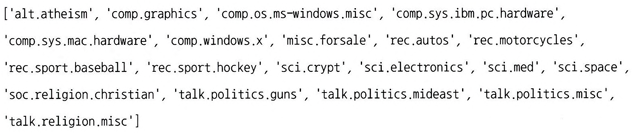

이 중 모터사이클, 야구, 그래픽스, 윈도우, 중동, 기독교, 전자공학, 의학의 8개 주제를 추출하고 이들 
텍스트에 LDA 기반의 토픽 모델링을 적용해 보겠습니다.
사이킷런은 LDA(Latent Dirichlet Allocation) 기반의 토픽 모델링을 LatentDirichletAllocation 클 
래스로 제공합니다. 사이킷런 초기 버전에는 LDA 토픽 모델링을 제공하지 않았으나 gensim과 같은 
토픽 모델링 패키지가 인기를 끌면서 사이킷런도 LDA를 제공하게 됐습니다.
먼저 LDA 토픽 모델링을 위해 fetch_20newsgroups( ) API는 categories 파라미터를 통해 필요한 
주제만 필터링해 추출하고 추출된 텍스트를 Count 기반으로 벡터화 변환하겠습니다. LDA는 Count 
기반의 벡터화만 사용합니다. max_features=1000으로 word 피처의 개수를 제한하고, ngram_ 
range는 (1,2)로 설정하고 피처 벡터화 변환하겠습니다.


In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.decomposition import LatentDirichletAllocation

# 모터사이클, 야구, 그래픽스, 윈도우즈, 중동, 기독교, 전자공학, 의학 8개 주제를 추출. 
cats = ['rec.motorcycles', 'rec.sport.baseball', 'comp.graphics', 'comp.windows.x','talk.politics.mideast', 'soc.religion.christian', 'sci.electronics', 'sci.med']

# 위에서 cats 변수로 기재된 카테고리만 추출. featch_20newsgroups( )의 categories에 cats 입력 
news_df= fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'),categories=cats, random_state=0)

# LDA는 Count 기반의 벡터화만 적용합니다.
count_vect = CountVectorizer(max_df=0.95, max_features=1000, min_df=2, stop_words='english', ngram_range=(1, 2))
feat_vect = count_vect.fit_transform(news_df.data) 
print('CountVectorizer Shape:', feat_vect.shape)

CountVectorizer Shape: (7862, 1000)


CountVectorizer 객체 변수인 feat_vect 모두 7862개의 문서가 1000개의 피처로 구성된 행렬 데이터 
입니다. 이렇게 피처 벡터화된 데이터 세트를 기반으로 LDA 토픽 모델링을 수행합니다. 토픽의 개수 
는 위의 뉴스그룹에서 추출한 주제와 동일한 8개로 정하겠습니다. LatentDirichletAllocation 클래스 
의 n_components 파라미터를 이용해 이 토픽 개수를 조정합니다(random_state 값은 예제를 수행할 
때마다 결과가 똑같게 하기 위해 입력합니다).

In [2]:
lda = LatentDirichletAllocation(n_components=8, random_state=0) 
lda.fit(feat_vect)

LatentDirichletAllocation(n_components=8, random_state=0)

In [3]:
print(lda.components_.shape) 
lda.components_

(8, 1000)


array([[4.76246946e+01, 1.30590464e+02, 1.92572328e+01, ...,
        3.39537619e+01, 7.42649755e+01, 7.17392109e+01],
       [1.25919475e-01, 1.94924852e+00, 1.25043526e-01, ...,
        1.06955618e+02, 1.25080664e-01, 9.79579308e+01],
       [3.49904576e+02, 1.25142960e-01, 1.52107210e+02, ...,
        1.25118746e-01, 3.58796514e+01, 1.25025882e-01],
       ...,
       [2.40981635e+01, 2.04404394e+01, 8.55554560e+00, ...,
        2.35736693e+01, 6.47339848e+00, 1.55639443e+01],
       [1.25082857e-01, 1.27714385e-01, 1.25009975e-01, ...,
        1.25052378e+02, 1.25124695e-01, 4.03879645e+01],
       [1.25121653e-01, 1.77786583e+00, 1.25095618e-01, ...,
        1.86886165e+02, 1.25059007e-01, 1.25135497e-01]])

components_는 array[8, 1000]으로 구성돼 있습니다. 8개의 토픽별로 1000개의 word 피처가 해당 토픽 별로 연관도 값을 가지고 있습니다. 즉, components_ array의 0번째 row, 10번째 col에 있는 값은 Topic #0에 대해서 피처 벡터화된 행렬에서 10번째 칼럼에 해당하는 피처가 Topic #0에 연관되는 수치 값을 가지고 있습니다. lda_model.components_ 값만으로는 각 토픽별 word 연관도를 보기가 
어렵습니다. display_topics( ) 함수를 만들어서 각 토픽별로 연관도가 높은 순으로 Word를 나열해 보겠습니다.

In [4]:
def display_topics(model, feature_names, no_top_words):
    for topic_index, topic in enumerate(model.components_):
        print('Topic #', topic_index)
        # components, array에서 가장 값이 큰 순으로 정렬했을 때, 그 값의 array 인덱스를 반환. 
        topic_word_indexes = topic.argsort()[::-1] 
        top_indexes=topic_word_indexes[:no_top_words]
        
        # top_indexes대상인 인덱스별로 feature_names에 해당하는 word feature 추출 후 join으로 concat 
        feature_concat = ' '.join([feature_names[i] for i in top_indexes]) 
        print(feature_concat)

# CountVectorizer 객체 내의 전체 word의 명칭을 get_features_names( )를 통해 추출 
feature_names = count_vect.get_feature_names_out()
# 토픽별 가장 연관도가 높은 word를 15개만 추출 
display_topics(lda, feature_names, 15)

Topic # 0
year 10 game medical health years 12 team 1993 20 disease cancer games patients good
Topic # 1
know don just said like people didn time did say think going went got right
Topic # 2
image file jpeg program color gif output images format files entry bit 00 use 03
Topic # 3
armenian armenians turkish people turkey government armenia 000 genocide turks muslim greek russian war university
Topic # 4
israel jews dos jewish israeli dos dos arab state arabs water palestinian people ed peace palestinians
Topic # 5
edu graphics com available window server ftp software mail use data information version windows sun
Topic # 6
god people jesus think church believe does christ say christian don know christians just bible
Topic # 7
like just use don good ve time make think problem used way does bike need


20 뉴스그룹에서 모터사이클, 야구, 그래픽스, 윈도우즈, 중동（Middle East）, 기독교, 전자공학, 의학 8개를 주제로 추출했는데, 8개의 토픽으로 모델링이 잘 됐는지 확인해 보겠습니다. Topic #0의 경우 일부 불분명한 주제어들이 있지만 주로 의학에 관련된 주제어가 추출됐습니다. Topic #1의 경우는 명확하지 않고 일반적인 단어가 주를 이루고 있습니다. Topic #2는 컴퓨터 그래픽스 영역의 주제어가 다수 포함되어 있습니다. Topic #3은 아쉽게도 일반적인 단어로 주제어가 추출됐습니다. Topic #4는 명확하게 중동 영역의 주제어가 추출됐습니다. Topic #5는 일부 컴퓨터 그래픽스 영역의 주제어를 포함하고 있지만, 전반적인 컴퓨터 관련 용어들을 가지고 있어서 8개 토픽 중 하나로 매핑하기는 어렵습니다. Topic #6은 명확하게 기독교 관련 주제어가 추출됐습니다. 마지막으로 Topic #7은 윈도우 운영체제와 관련된 주제어가 추출됐습니다. Topic #1, Topic #3 Topic #5가 주로 애매한 주제어가 추출됐습니다. 특히 모터사이클, 야구 주제의 경우 명확한 주제어가 추출되지 않았습니다.

## 8-8. 문서 유사도

### 문서 유사도 측정 방법 - 코사인 유사도
문서와 문서 간의 유사도 비교는 일반적으로 코사인 유사도(Cosine Similarity)를 사용합니다. 코사인 
유사도는 벡터와 벡터 간의 유사도를 비교할 때 벡터의 크기보다는 벡터의 상호 방향성이 얼마나 유사 
한지에 기반합니다. 즉, 코사인 유사도는 두 벡터 사이의 사잇각을 구해서 얼마나 유사한지 수치로 적 
용한 것입니다


### 두 벡터 사잇각

In [5]:
import numpy as np

def cos_similarity(v1, v2):
    dot_product = np.dot(v1 , v2)
    l2_norm = (np.sqrt(sum(np.square(v1))) * np.sqrt(sum(np.square(v2)))) 
    similarity = dot_product / l2_norm
    return similarity

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

doc_list = ['if you take the blue pill, the story ends','if you take the red pill, you stay in Wonderland','if you take the red pill, I show you how deep the rabbit hole goes']
tfidf_vect_simple = TfidfVectorizer()
feature_vect_simple = tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)

(3, 18)


In [7]:
# TFidfVectorizer로 transform()한 결과는 희소 행렬이므로 밀집 행렬로 변환. 
feature_vect_dense = feature_vect_simple.todense()

# 첫 번째 문장과 두 번째 문장의 피처 벡터 추출
vect1 = np.array(feature_vect_dense[0]).reshape(-1, ) 
vect2 = np.array(feature_vect_dense[1]).reshape(-1, )

# 첫 번째 문장과 두 번째 문장의 피처 벡터로 두 개 문장의 코사인 유사도 추출 
similarity_simple = cos_similarity(vect1, vect2)
print('문장 1, 문장 2 Cosine 유사도: {0: .3f}'.format(similarity_simple))

문장 1, 문장 2 Cosine 유사도:  0.402


In [8]:
vect1 = np.array(feature_vect_dense[0]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, ) 
similarity_simple = cos_similarity(vect1, vect3 ) 
print('문장 1, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))
vect2 = np.array(feature_vect_dense[1]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, ) 
similarity_simple = cos_similarity(vect2, vect3 ) 
print('문장 2, 문장 3 Cosine 유사도: {0: .3f}'.format(similarity_simple))

문장 1, 문장 3 Cosine 유사도: 0.404
문장 2, 문장 3 Cosine 유사도:  0.456


In [9]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple) 
print(similarity_simple_pair)

[[1.         0.40207758 0.40425045]]


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple[1:]) 
print(similarity_simple_pair)

[[0.40207758 0.40425045]]


In [11]:
similarity_simple_pair = cosine_similarity(feature_vect_simple, feature_vect_simple) 
print(similarity_simple_pair)
print('shape:', similarity_simple_pair.shape)

[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


### Opinion Review 데이터 세트를 이용한 문서 유사도 측정

In [12]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# 필수 NLTK 데이터 다운로드
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

def LemNormalize(text):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token) for token in word_tokenize(text)]

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [13]:
import pandas as pd 
import glob, os 
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.cluster import KMeans
path = r"C:\Users\User\OneDrive\바탕 화면\topics"
all_files = glob.glob(os.path.join(path, "*.data")) 
filename_list = [] 
opinion_text = []

for file_ in all_files:
    df = pd.read_table(file_, index_col=None, header=0, encoding='latin1') 
    filename_ = file_.split('\\') [-1]
    filename = filename_.split('.' )[0] 
    filename_list.append(filename) 
    opinion_text.append(df.to_string())
document_df = pd.DataFrame({'filename':filename_list, 'opinion_text':opinion_text})

tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english', ngram_range=(1 , 2), min_df=0.05, max_df=0.85 ) 
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0) 
km_cluster.fit(feature_vect) 
cluster_label = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_ 
document_df['cluster_label'] = cluster_label

c:\Users\User\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


In [14]:
from sklearn.metrics.pairwise import cosine_similarity

# clusterjab=2인 데이터는 호텔로 군집화된 데이터임. DataFrame에서 해당 인덱스를 추출 
hotel_indexes = document_df[document_df['cluster_label']==2] .index 
print('호텔로 클러스터링 된 문서들의 DataFrame Index: ', hotel_indexes)

# 호텔로 군집화된 데이터 중 첫 번째 문서를 추출해 파일명 표시.
comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('##### 비교 기준 문서명', comparison_docname, ' 와 타 문서 유사도######')
''' document_df에서 추출한 Index 객체를 feature_vect로 입력해 호텔 군집화된 feature_vect 추출 
이를 이용해 호텔로 군집화된 문서 중 첫 번째 문서와 다른 문서 간의 코사인 유사도 측정.'''
similarity_pair = cosine_similarity(feature_vect[hotel_indexes[0]], feature_vect[hotel_indexes]) 
print(similarity_pair)

호텔로 클러스터링 된 문서들의 DataFrame Index:  Index([0, 2, 3, 4, 8, 9, 11, 19, 26, 33, 34, 35, 36, 41, 42, 43, 47, 48, 49,
       50],
      dtype='int64')
##### 비교 기준 문서명 accuracy_garmin_nuvi_255W_gps  와 타 문서 유사도######
[[1.         0.03089126 0.03992515 0.03440963 0.32390375 0.19830889
  0.03942555 0.02328587 0.0347797  0.1018338  0.15640861 0.03461385
  0.03519983 0.03784019 0.03055161 0.21553311 0.01812863 0.18828502
  0.01803702 0.12378794]]


In [15]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as pit 
%matplotlib inline

# 첫번째 문서와 타 문서간 유사도가 큰 순으로 정렬한 인덱스 추출하되 자기 자신은 제외.
sorted_index = similarity_pair.argsort()[:,::-1 ]
sorted_index = sorted_index[:, 1:]

# 유사도가 큰 순으로 hotel_indexes를 추출하여 재정렬.
hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]

# 유사도가 큰 순으로 유사도 값을 재정렬하되 자기 자신은 제외
hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1 ]
hotel_1_sim_value = hotel_1_sim_value[1:]

# 유사도가 큰 순으로 정렬된 인덱스와 유사도 값을 이용해 파일명과 유사도값을 막대 그래프로 시각화 
hotel_1_sim_df = pd.DataFrame()
hotel_1_sim_df['filename'] = document_df.iloc[hotel_sorted_indexes]['filename']
hotel_1_sim_df['similarity' ] = hotel_1_sim_value
print('가장 유사도가 큰 파일명 및 유사도:\n', hotel_1_sim_df.iloc[0, :])
sns.barplot(x='similarity', y='filename',data=hotel_1_sim_df)
pit.title(comparison_docname)

가장 유사도가 큰 파일명 및 유사도:
 filename      directions_garmin_nuvi_255W_gps
similarity                           0.323904
Name: 8, dtype: object


Text(0.5, 1.0, 'accuracy_garmin_nuvi_255W_gps')

## 8-9. 한글 텍스트 처리 - 네이버 영화 평점 감성 분석

이번 절에서는 네이버 영화 평점 데이터를 기반으로 감성 분석을 적용해 보겠습니다. 이전에 먼저 한글 
NLP 처리에서 주의할 점과 대표적인 파이썬 기반의 한글 형태소 패키지인 KoNLPy를 소개하겠습니다.

### 한글 NLP 처리의 어려움

일반적으로 한글 언어 처리는 영어 등의 라틴어 처리보다 어렵습니다. 그 주된 원인은 ‘띄어쓰기’와 ‘다 
양한 조사’ 때문입니다. 잘 알다시피 한글은 띄어쓰기를 잘못하면 의미가 왜곡되어 전달될 수 있습니 
다. ‘아버지가 방에 들어가신다’를 잘못 띄어쓰기 하면 ‘아버지 가방에 들어가신다’가 되어 의미가 왜곡 
됩니다. 영어의 경우 띄어쓰기를 잘못하면 의미가 왜곡되는 게 아니라 잘못된 또는 없는 단어로 인식되 
는 게 대부분입니다. My father enters a room을 My fatherenters a room으로 잘못 띄어쓰기를 하 
면 잘못된 단어로 분석에서 제외될 수 있습니다. 더구나 영어의 띄어쓰기는 매우 명확하므로 초등학생 
이라도 거의 완벽하게 띄어쓰기를 할 수 있습니다. 하지만 한글의 띄어쓰기는 고등교육을 받은 사람이 
라도 틀리는 경우가 종종 발생합니다.
또 하나 중요한 이슈는 바로 ‘조사’입니다. 조사는 주어나 목적어를 위해 추가되며, 워낙 경우의 수가 많 
기 때문에 어근 추출(Stemming/Lemmatization) 등의 전처리 시 제거하기가 까다롭습니다. 예를 들 
어 ‘집’이라는 어근 단어를 기준으로 집은, 집이, 집으로, 집에서, 집에 등 다양한 형태의 조사가 존재합 
니다. 또한 ‘너희 집은 어디 있니?’에서 ‘집은’의 ‘은’이 뜻하는 것이 조사인지 아니면 은(銀)인지 구분하기도 어렵습니다(더구나 ‘집은’을 ‘집 은’으로 띄어쓰기를 잘못하면 더욱 그렇습니다).
한글의 과학성은 세계적으로 인정받고 있지만, 이러한 이슈로 인해서 상대적으로 라틴어 계열의 언어 
보다 NLP 처리가 어려운 문제가 있습니다.

### KoNLPy 소개

KoNLPy는 파이썬의 대표적인 한글 형태소 패키지입니다. 형태소의 사전적인 의미는 ‘단어로서 의미 
를 가지는 최소 단위’로 정의할 수 있습니다. 형태소 분석(Morphological analysis)이란 말뭉치를 이 
러한 형태소 어근 단위로 쪼개고 각 형태소에 품사 태깅(POS tagging)을 부착하는 작업을 일반적으로 
지칭합니다.
KoNLPy 이전에는 파이썬 기반의 형태소 분석 프로그램이 거의 없었으며, 대부분의 형태소 분석은 C/ 
C十十과Java 기반 패키지로 개발됐습니다. KoNLPy는 기존의 C/C+十, Java로 잘 만들어진 한글 형태 
소 엔진을 파이썬 래퍼(Wrapper) 기반으로 재작성한 패키지입니다. 기존의 엔진은 그대로 유지한 채 
파이썬 기반에서 인터페이스를 제공하기 때문에 검증된 패키지의 안정성을 유지할 수 있습니다. 꼬꼬 
마(Kkma), 한나눔(Hannanum), Komoran, 은전한닢 프로젝트(Mecab), Twitter와 같이 5개의 형 
태소 분석 모듈을 KoNLPy에서 모두 사용할 수 있습니다. 안타깝게도 뛰어난 형태소 분석으로 인정받 
고 있는 Mecab의 경우는 윈도우 환경에서는 구동되지 않습니다. Mecab을 사용하고자 한다면 현재까 
지는 리눅스 환경의 KoNLPy에서만 가능합니다

### 데이터 로딩

테스트 데이터가 별도로 있으니 이를 이용해 평가하겠습니다. 새로운 주피터 노트북을 생성하고 내 
려받은 파일을 생성한 주피터 노트북이 있는 디렉터리로 이동합니다. 먼저 ratings_train.txt 파일을 
DataFrame으로 로딩하고 데이터를 살펴보겠습니다. Ratings_train.txt 파일은 탭(\t)으로 칼럼이 분리돼 있으므로 read_csv( )의 sep 파라미터를 ‘\f로 설정해 DataFrame으로 생성합니다. 한글로 된 
문서를 DataFrame으로 로딩할 때 인코딩 이슈가 발생할 수 있습니다. 아래와 같이 pd.read_csv()시 
encoding을 cp949로 설정합니다.

In [16]:
import pandas as pd
train_df = pd.read_csv('ratings_train.txt', sep='\t', encoding='utf-8')
train_df.head(3)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


학습 데이터 세트의 0과 1의 Label 값 비율을 살펴보겠습니다. 1이 긍정, 0이 부정 감성입니다.

In [17]:
train_df['label'].value_counts( )

label
0    75173
1    74827
Name: count, dtype: int64

o과 1 의 비율이 어느 한 쪽으로 치우치지 않고 균등한 분포를 나타내고 있습니다. train_df의 경우 리 
뷰 텍스트를 가지는 ‘document’ 칼럼에 Null이 일부 존재하므로 이 값은 공백으로 변환합니다. 문자가 
아닌 숫자의 경우 단어적인 의미로 부족하므로 파이썬의 정규 표현식 모듈인 re를 이용해 이 역시 공백 
으로 변환합니다. 테스트 데이터 세트의 경우도 파일을 로딩하고 동일한 데이터 가공을 수행합니다.

In [18]:
import re

train_df = train_df.fillna('')
# 정규 표현식을 이용해 숫자를 공백으로 변경(정규 표현식으로 \d는 숫자를 의미함.) 
train_df['document'] = train_df['document'].apply( lambda x : re.sub(r"\d+", " ", x) )

# 테스트 데이터 세트를 로딩하고 동일하게 Null 및 숫자를 공백으로 변환
test_df = pd.read_csv('ratings_test.txt', sep='\t', encoding='utf-8')
test_df = test_df.fillna(' ')
test_df['document'] = test_df['document'].apply( lambda x: re.sub(r"\d+", " ", x) )

#id 칼럼 삭제 수행
train_df.drop('id', axis=1, inplace=True) 
test_df.drop('id', axis=1, inplace=True)

이제는 TF-IDF 방식으로 단어를 벡터화할 텐데, 먼저 각 문장을 한글 형태소 분석을 통해 형태소 
단어로 토큰화하겠습니다. 한글 형태소 엔진은 SNS 분석에 적합한 Twitter 클래스를 이용하겠습 
니다. Twitter 객체의 morphs( ) 메서드를 이용하면 입력 인자로 들어온 문장을 형태소 단어 형태 
로 토큰화해 list 객체로 반환합니다. 문장을 형태소 단어 형태로 반환하는 별도의 tokenizer 함수 
를 tw_tokenizer( )라는 이름으로 생성하겠습니다. 이 tw_tokenizer( ) 함수는 뒤에서 사이킷런의 
TfidfVectorizer 클래스의 tokenizer로 사용됩니다.

In [19]:
pip install konlpy

In [20]:
from konlpy.tag import Okt
twitter = Okt()

def tw_tokenizer(text):
    tokens_ko = twitter.morphs(text)
    return tokens_ko

사이킷런의 TfidfVectorizer를 이용해 TF-IDF 피처 모델을 생성하겠습니다. tokenizer는 위에서 만 
든 tw_tokenizer() 함수를 이용합니다. ngram은 (1,2), min_df=3, max_df는 상위 90%로 제한합 
니다.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import GridSearchCV
# Twitter 객체의 morphs( ) 객체를 이용한 tokenizer를 사용. ngram_range는 (1, 2)
tfidf_vect = TfidfVectorizer(tokenizer=tw_tokenizer, ngram_range=(1, 2), min_df=3, max_df=0.9) 
tfidf_vect.fit(train_df['document'])
tfidf_matrix_train = tfidf_vect.transform(train_df['document'])

로지스틱 회귀를 이용해 분류 기반의 감성 분석을 수행합니다. 로지스틱 회귀의 하이퍼 파라미터 c의 
최적화를 위해 GridSearchCV를 이용하겠습니다.

In [24]:
# 로지스틱 회귀를 이용해 감성 분석 분류 수행.
lg_clf = LogisticRegression(random_state=0, solver='liblinear')

# 파라미터 C 최적화를 위해 GridSearchCV를 이용.
params = { 'C': [1, 3.5, 4.5, 5.5, 10] }
grid_cv = GridSearchCV(lg_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1) 
grid_cv.fit(tfidf_matrix_train, train_df['label'])
print(grid_cv.best_params_, round(grid_cv.best_score_, 4))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
{'C': 3.5} 0.8593


c가 3.5일 때 최고 0.8593의 정확도를 보였습니다.
이제 테스트 세트를 이용해 최종 감성 분석 예측을 수행하겠습니다. 앞 절의 텍스트 분류 절에서도 말 
한 것처럼 테스트 세트를 이용해 예측할 때는 학습할 때 적용한 TfidfWctorizer를 그대로 사용해야 합 
니다. 그래야만 학습 시 설정된 TfidfVectorizer의 피처 개수와 테스트 데이터를TfidfWctorizer로 변 
환할 피처 개수가 같아집니다. 학습 데이터에 사용된 TfidfVectorizer 객체 변수인 tfidf_vect를 이용 
해 transform()을 테스트 데이터의 document 칼럼에 수행합니다

In [26]:
from sklearn.metrics import accuracy_score

# 학습 데이터를 적용한 TfidfVectorizer를 이용해 테스트 데이터를 TF-IDF 값으로 피처 변환함. 
tfidf_matrix_test = tfidf_vect.transform(test_df['document'])

# classifier는 GridSearchCV에서 최적 파라미터로 학습된 classifier를 그대로 이용 
best_estimator = grid_cv.best_estimator_
preds = best_estimator.predict(tfidf_matrix_test)

print ('Logistic Regression 정확도:', accuracy_score(test_df ['label'], preds))

Logistic Regression 정확도: 0.86172
